In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r"C:\Users\suraj\project\car ds (capstone)\cleancardata.csv")
data

,vehicle_uid,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_record_id,car_age,price_category,km_category,owner_count,fuel_transmission,brand,price_per_km,is_diesel
0,CAR_000001,Maruti 800 AC,2007,60000.0,70000.0,Petrol,Individual,Manual,First Owner,1,18,Low,Medium,0.0,Petrol_Manual,Maruti,0.86,0
1,CAR_000002,Maruti Wagon R LXI Minor,2007,135000.0,50000.0,Petrol,Individual,Manual,First Owner,2,18,Low,Medium,0.0,Petrol_Manual,Maruti,2.70,0
2,CAR_000003,Hyundai Verna 1.6 SX,2012,600000.0,100000.0,Diesel,Individual,Manual,First Owner,3,13,Low,Medium,0.0,Diesel_Manual,Hyundai,6.00,1
3,CAR_000004,Datsun RediGO T Option,2017,250000.0,46000.0,Petrol,Individual,Manual,First Owner,4,8,Low,Medium,0.0,Petrol_Manual,Datsun,5.43,0
4,CAR_000005,Honda Amaze VX i-DTEC,2014,450000.0,141000.0,Diesel,Individual,Manual,Second Owner,5,11,Low,High,0.0,Diesel_Manual,Honda,3.19,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4335,CAR_004336,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999.0,60000.0,Diesel,Individual,Manual,Second Owner,4336,11,Mid,High,0.0,Diesel_Manual,Hyundai,5.12,1
4336,CAR_004337,Hyundai i20 Magna 1.4 CRDi,2014,409999.0,80000.0,Diesel,Individual,Unknown,Second Owner,4337,11,Mid,High,0.0,Diesel_Manual,Hyundai,5.12,1
4337,CAR_004338,Maruti 800 AC BSIII,2009,110000.0,83000.0,Petrol,Individual,Manual,Second Owner,4338,16,Low,High,0.0,Petrol_Manual,Maruti,1.33,0
4338,CAR_004339,Hyundai Creta 1.6 CRDi SX Option,2016,865000.0,60000.0,Diesel,Individual,Manual,First Owner,4339,9,High,High,0.0,Diesel_Manual,Hyundai,9.61,1


In [3]:
X = data.drop("price_category", axis =1)

In [4]:
X = data.drop(["vehicle_uid","name"], axis =1)

In [5]:
Y = data["price_category"]

In [6]:
# Q2

In [7]:
from sklearn.preprocessing import StandardScaler,LabelEncoder

In [8]:
scaler = StandardScaler()

In [9]:
label = LabelEncoder()

In [10]:
col = ["fuel","seller_type","transmission","owner","price_category","km_category","fuel_transmission","brand"]

In [11]:
for i in col:
    X[i] = label.fit_transform(X[i])

In [12]:
X=scaler.fit_transform(X)

In [13]:
X

array([[-1.44507431, -0.64241963,  0.09832559, ...,  0.35817253,
        -0.02292873, -0.99219635],
       [-1.44507431, -0.58524661, -0.34943325, ...,  0.35817253,
        -0.02244466, -0.99219635],
       [-0.2587948 , -0.23077383,  0.76996384, ..., -0.81667398,
        -0.02157648,  1.00786503],
       ...,
       [-0.97056251, -0.60430428,  0.38936883, ...,  0.35817253,
        -0.02280508, -0.99219635],
       [ 0.69022881, -0.02876247, -0.12555383, ..., -0.81667398,
        -0.02062675,  1.00786503],
       [ 0.69022881,  2.71249365, -0.57331267, ...,  1.0924516 ,
        -0.02167646, -0.99219635]], shape=(4340, 16))

In [14]:
#Q3

Text(0.5, 1.0, 'the relationship between safety, selling price indicators')

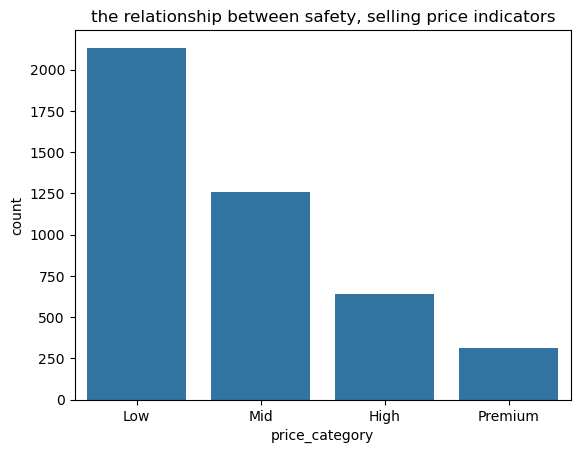

In [15]:
sns.countplot(x="price_category",data= data)
plt.title("the relationship between safety, selling price indicators")

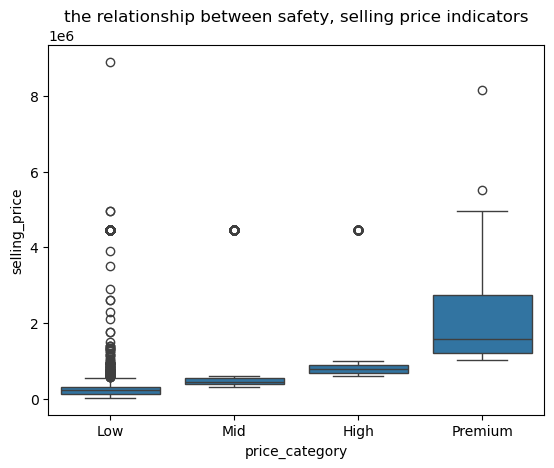

In [16]:
sns.boxplot(x="price_category",y="selling_price",data = data)
plt.title("the relationship between safety, selling price indicators")
plt.show()

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from  sklearn.svm import SVC

In [18]:
x_train , x_test , y_train , y_test = train_test_split(X,Y, test_size=0.2,random_state=42)

In [19]:
model =  SVC(C=45,kernel="poly")

In [20]:
model.fit(x_train,y_train)

,C,45
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [21]:
model.score(x_train,y_train)

1.0

In [22]:
model.score(x_test,y_test)

0.8894009216589862

In [23]:
yp = model.predict(x_test)

In [24]:
accuracy_score(y_test,yp)

0.8894009216589862

In [25]:
a= confusion_matrix(y_test,yp)

<Axes: >

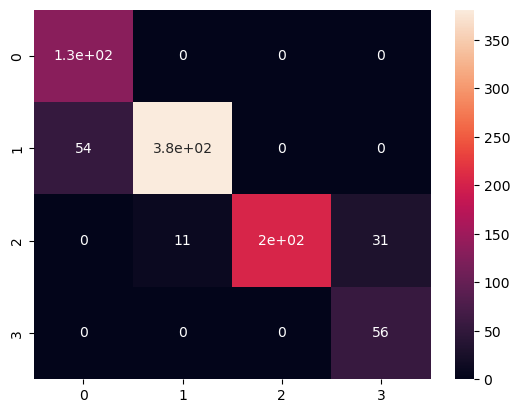

In [26]:
sns.heatmap(a, annot=True)

In [28]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
model2 = RandomForestClassifier()

In [30]:
model2.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
model2.score(x_train,y_train)

1.0

In [32]:
model2.score(x_test,y_test)

0.9435483870967742

In [35]:
yp2 = model2.predict(x_test)

In [36]:
accuracy_score(y_test,yp2)

0.9435483870967742

In [38]:
b= confusion_matrix(y_test,yp2)

<Axes: >

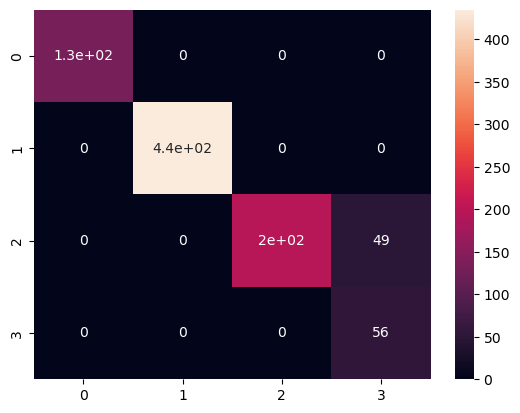

In [39]:
sns.heatmap(b, annot=True)